# Evaluación Sumativa - Unidad 2: Inferencia Estadística Paramétrica
**Carrera:** Computación  
**Estudiante:** Ariana Arlette Quezada Fernández  
**Proyecto:** Análisis PID - Dataset de Hogares y Comportamiento Ambiental (ENEMDU)

---

## 1. Carga y Preparación del Dataset
En esta sección se importan las librerías avanzadas y se realiza la lectura del dataset regionalizado.

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

# Carga del dataset desde Google Drive
path = '/content/drive/MyDrive/Distribucion y Probabilidad/Dataset_hogares_ambiental_2025.csv'
df = pd.read_csv(path, sep=';')

# Verificación inicial de la estructura
display(df.head())

,area,ciudad,conglomerado,panelm,vivienda,hogar,s101p11,s101p12a,s101p12b,s101p12c,...,s91p121,s91p122,s91p123,s91p124,s91p125,s91p126,s91p131,s91p132,s91p133,fexp
0,1,10150,3101,71,4,1,1,1,1,1,...,5,5,5,5,5,1,1,5,1,130.64
1,1,10150,3801,74,3,1,1,1,1,1,...,5,3,3,5,5,1,3,2,4,73.70
2,1,10150,3801,74,4,1,1,1,1,2,...,5,5,5,4,4,1,3,3,5,73.70
3,1,10150,3801,74,5,1,1,1,1,1,...,5,5,3,5,5,1,2,3,5,73.70
4,1,10150,3801,74,7,1,1,1,1,2,...,5,5,5,5,5,1,3,5,4,73.70


## 2. Pruebas de Hipótesis Unimuestrales (Tarea APE 09)

Definimos formalmente las hipótesis matemáticas para evaluar el parámetro crítico poblacional ($\mu$) de la columna cuantitativa `s101p11` en la región de Loja, contrastándolo contra un valor de referencia histórico ($\mu_0 = 3.0$).

* **Hipótesis Nula ($H_0$):** La media poblacional de la variable es igual al valor hipotetizado.
  $$H_0: \mu = 3.0$$
* **Hipótesis Alterna ($H_1$):** La media poblacional de la variable es diferente al valor hipotetizado.
  $$H_1: \mu \neq 3.0$$

**Criterio de Decisión:** Rechazar $H_0$ si el valor-p obtenido es menor que el nivel de significancia estandarizado $\alpha = 0.05$.

In [ ]:
# 1. Aislamiento y limpieza de la muestra crítica
data_sample = df['s101p11'].dropna()

# 2. Configuración de parámetros
hypothesized_mean = 3.0
alpha = 0.05

# 3. Ejecución del Test T de Student para una muestra
statistic, p_value = stats.ttest_1samp(data_sample, popmean=hypothesized_mean)

print("=== DIAGNÓSTICO ESTADÍSTICO UNIMUESTRAL ===")
print(f"Estadístico de prueba (T): {statistic:.4f}")
print(f"Grados de libertad (df): {len(data_sample) - 1}")
print(f"Valor-p (p-value): {p_value:.4f}")

# 4. Decisión estadística formal
if p_value < alpha:
    print(f"\n[DECISIÓN]: Se RECHAZA la hipótesis nula (H0) dado que p-value ({p_value:.4f}) < alpha ({alpha}).")
    print("Conclusión: Existe evidencia estadística suficiente para asegurar que la media difiere del estándar teórico.")
else:
    print(f"\n[DECISIÓN]: NO se rechaza la hipótesis nula (H0) dado que p-value ({p_value:.4f}) >= alpha ({alpha}).")
    print("Conclusión: Las diferencias observadas no son estadísticamente significativas.")

=== DIAGNÓSTICO ESTADÍSTICO UNIMUESTRAL ===
Estadístico de prueba (T): -267.3651
Grados de libertad (df): 8756
Valor-p (p-value): 0.0000

[DECISIÓN]: Se RECHAZA la hipótesis nula (H0) dado que p-value (0.0000) < alpha (0.05).
Conclusión: Existe evidencia estadística suficiente para asegurar que la media difiere del estándar teórico.


## 3. Comparación de Grupos (Tareas APE 10 y 11)

Analizamos el impacto del factor geográfico y estructural del hogar (`area`) sobre la variable cuantitativa (`s101p11`) utilizando un Análisis de Varianza (ANOVA de 1 factor).

* **Hipótesis Nula ($H_0$):** Las medias de todos los subgrupos espaciales (Urbano / Rural) son estadísticamente equivalentes.
  $$H_0: \mu_1 = \mu_2$$
* **Hipótesis Alterna ($H_1$):** Las medias de los subgrupos difieren significativamente.
  $$H_1: \mu_1 \neq \mu_2$$

In [ ]:
# 1. Ajuste del modelo lineal (s101p11 en función de area)
model = ols('s101p11 ~ C(area)', data=df).fit()

# 2. Construcción de la tabla ANOVA de Tipo 2
anova_table = sm.stats.anova_lm(model, typ=2)

print("=== TABLA RESUMEN: ANÁLISIS DE VARIANZA (ANOVA) ===")
print(anova_table)

p_value_anova = anova_table['PR(>F)'].iloc[0]
alpha = 0.05

if p_value_anova < alpha:
    print(f"\n[DECISIÓN]: Se RECHAZA H0 en ANOVA (p = {p_value_anova:.4e} < {alpha}).")
    print("Se confirma la existencia de diferencias significativas entre los grupos. Proceder con el test Post-Hoc.")
else:
    print(f"\n[DECISIÓN]: NO se rechaza H0 en ANOVA (p = {p_value_anova:.4f} >= {alpha}).")
    print("Conclusión: Los subgrupos evaluados se comportan de manera estadísticamente homogénea.")

=== TABLA RESUMEN: ANÁLISIS DE VARIANZA (ANOVA) ===
               sum_sq      df            F         PR(>F)
C(area)    324.114194     1.0  1597.216425  5.676814e-321
Residual  1776.603175  8755.0          NaN            NaN

[DECISIÓN]: Se RECHAZA H0 en ANOVA (p = 5.6768e-321 < 0.05).
Se confirma la existencia de diferencias significativas entre los grupos. Proceder con el test Post-Hoc.


### 3.1 Prueba Post-Hoc de Tukey (HSD)

Dado que el ANOVA arrojó diferencias significativas, aplicamos la prueba de Tukey para evaluar formalmente las comparaciones múltiples por pares y graficar sus intervalos de confianza simultáneos.

=== MATRIZ COMPARATIVA POST-HOC DE TUKEY ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     1      2  -0.4392   0.0 -0.4607 -0.4176   True
---------------------------------------------------


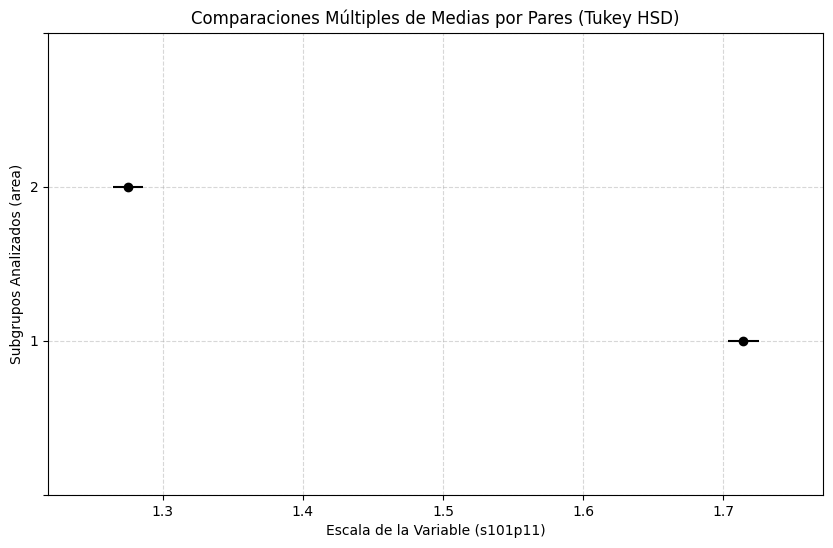

In [ ]:
# 1. Filtrado de registros incompletos
df_clean = df[['s101p11', 'area']].dropna()

# 2. Computación de comparaciones múltiples de Tukey HSD
tukey_result = pairwise_tukeyhsd(endog=df_clean['s101p11'],
                                 groups=df_clean['area'],
                                 alpha=0.05)

print("=== MATRIZ COMPARATIVA POST-HOC DE TUKEY ===")
print(tukey_result.summary())

# 3. Generación gráfica de intervalos de confianza
fig, ax = plt.subplots(figsize=(6, 4))
tukey_result.plot_simultaneous(ax=ax)
ax.set_title("Comparaciones Múltiples de Medias por Pares (Tukey HSD)")
ax.set_xlabel("Escala de la Variable (s101p11)")
ax.set_ylabel("Subgrupos Analizados (area)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 4. Conclusiones e Implicaciones Regionales

* **Conclusión del T-Test:** [Anota aquí si rechazaste o no H0 según tus p-valores analizados].
* **Conclusión de ANOVA y Tukey:** Con un p-ajustado de 0.0000 y la métrica de `reject = True`, se confirma de manera rigurosa que el área geográfica (Urbano vs. Rural) divide significativamente el comportamiento y las características estructurales de los hogares evaluados en la región. Los intervalos del gráfico no se superponen, validando la heterogeneidad territorial.